# GTSRB: CNN-3 vs CNN-5 in TensorFlow and PyTorch

**Author:** Lưu Anh Dũng (B23DCDK036) · E23CNPM02 · Intelligent System Development · Assignment 05

**GTSRB** (German Traffic Sign Recognition Benchmark, IJCNN 2011) = 51,839 photos of traffic signs taken from a
moving car, resized to 32×32 color, **43 classes** (speed limits, stop, yield, priority road, …). Source: Kaggle
[`harbhajansingh21/german-traffic-sign-dataset`](https://www.kaggle.com/datasets/harbhajansingh21/german-traffic-sign-dataset).

What makes it hard: 43 classes, some with ~10× more images than others, very dark or blurred photos, and
look-alike signs (e.g. "speed limit 30" vs "80").

| Run ID | Framework | Model |
|---|---|---|
| `GT-TF-CNN-3` | TensorFlow/Keras | 3 convolutional layers |
| `GT-TF-CNN-5` | TensorFlow/Keras | 5 convolutional layers |
| `GT-PT-CNN-3` | PyTorch | 3 convolutional layers |
| `GT-PT-CNN-5` | PyTorch | 5 convolutional layers |

Sections 1–5 explain the method. Results are discussed in sections 6–7.

## 1. Setup

Seed 42 everywhere (same weights, batch order and dropout on every rerun). PyTorch device: `cuda` → `mps` → `cpu`;
TensorFlow uses an NVIDIA (Linux/WSL2) or Apple GPU by itself, otherwise the CPU. TensorFlow takes GPU memory only
as needed, so PyTorch can share the GPU. `A5_SMOKE=1` = quick test run.

In [1]:
import copy
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


SEED = 42
warnings.filterwarnings("ignore", category=UserWarning)

import tensorflow as tf
import keras
from keras import layers

keras.utils.set_random_seed(SEED)

import torch
import torch.nn as nn

torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available() else "cpu")

print("TensorFlow", tf.__version__, "| GPUs:", tf.config.list_physical_devices("GPU"))
print("PyTorch", torch.__version__, "| device:", DEVICE)

TensorFlow 2.22.0-rc0 | GPUs: []
PyTorch 2.14.0+cpu | device: cpu


**Helper functions** (no model code): project paths, the saved split, test metrics, result files and plots.
Settings shared by both frameworks: batch 256, max 20 epochs, early-stopping patience 3, learning rate 0.001.

In [2]:
import json
import os
import random
from pathlib import Path

from sklearn.metrics import (accuracy_score, average_precision_score, confusion_matrix, f1_score,
                             precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import train_test_split

SMOKE = os.environ.get("A5_SMOKE") == "1"          # quick test: small subsample, 2 epochs


def find_root():
    """assignment_05/ = first folder above the working directory that has dataset/ and notebook/."""
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "dataset").is_dir() and (p / "notebook").is_dir():
            return p
    return here.parent


ROOT = find_root()
DATA_DIR = Path(os.environ.get("A5_DATA_DIR", ROOT / "dataset"))
RESULTS_DIR = ROOT / "notebook" / "results" / ("smoke" if SMOKE else "")
MODELS_DIR = ROOT / "notebook" / "models" / ("smoke" if SMOKE else "")
FIG_DIR = ROOT / "report" / "images" / ("smoke" if SMOKE else "")
for d in (RESULTS_DIR, MODELS_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 256
EPOCHS = 2 if SMOKE else 20
PATIENCE = 3
LEARNING_RATE = 1e-3
SMOKE_SIZE = {"train": 2000, "validation": 500, "test": 500}

random.seed(SEED)
np.random.seed(SEED)
print("project folder:", ROOT, "| smoke run:", SMOKE, "| epochs:", EPOCHS, "| batch size:", BATCH_SIZE)


def find_file(code, name):
    """Find `name` anywhere under dataset/<code>/ (unzipping may add a subfolder)."""
    base = DATA_DIR / code.lower()
    hits = sorted(base.rglob(name))
    if not hits:
        raise FileNotFoundError(f"{name} not found under {base}; see dataset/README.md")
    return hits[0]


def make_or_load_splits(code, y, n_sample=None):
    """Stratified 70/15/15 split of row indices, saved once to dataset/<code>/splits.npz."""
    path = DATA_DIR / code.lower() / "splits.npz"
    n_sample = min(n_sample or len(y), len(y))
    splits = None
    if path.exists():
        saved = np.load(path)
        splits = {k: saved[k] for k in ("train", "validation", "test")}
        if sum(len(v) for v in splits.values()) != n_sample:
            splits = None
    if splits is None:
        idx = np.arange(len(y))
        if n_sample < len(y):
            idx, _ = train_test_split(idx, train_size=n_sample, stratify=y, random_state=SEED)
        train, rest = train_test_split(idx, train_size=0.70, stratify=y[idx], random_state=SEED)
        val, test = train_test_split(rest, test_size=0.50, stratify=y[rest], random_state=SEED)
        splits = {"train": np.sort(train), "validation": np.sort(val), "test": np.sort(test)}
        np.savez(path, **splits)
    if SMOKE:
        rng = np.random.default_rng(SEED)
        splits = {k: np.sort(rng.choice(v, min(SMOKE_SIZE[k], len(v)), replace=False)) for k, v in splits.items()}
    return splits


def classification_metrics(y_true, y_pred, y_score=None, binary=False):
    """Accuracy + macro precision/recall/F1; for binary tasks also positive-class F1, ROC-AUC, AP."""
    m = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }
    if binary:
        m["f1_positive"] = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
        m["roc_auc"] = roc_auc_score(y_true, y_score)
        m["average_precision"] = average_precision_score(y_true, y_score)
    return {k: float(v) for k, v in m.items()}


class Stopwatch:
    def __enter__(self):
        self._start = time.perf_counter()
        return self

    def __exit__(self, *exc):
        self.seconds = time.perf_counter() - self._start


def save_result(record):
    (RESULTS_DIR / f"{record['run_id']}.json").write_text(json.dumps(record, indent=2), encoding="utf-8")


def load_results(run_ids):
    paths = [RESULTS_DIR / f"{rid}.json" for rid in run_ids]
    return [json.loads(p.read_text(encoding="utf-8")) for p in paths if p.exists()]


def savefig(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")


def plot_history(history, run_id):
    """Figure with 2 plots: loss and accuracy per epoch, train vs validation."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
    epochs = np.arange(1, len(history["loss"]) + 1)
    for ax, key, title in [(axes[0], "loss", "Loss"), (axes[1], "accuracy", "Accuracy")]:
        ax.plot(epochs, history[key], marker="o", label="train")
        ax.plot(epochs, history[f"val_{key}"], marker="o", label="validation")
        ax.set_title(f"{run_id}: {title}"); ax.set_xlabel("epoch"); ax.grid(alpha=0.3); ax.legend()
    fig.tight_layout(); savefig(fig, f"{run_id}_curves"); plt.show()


def plot_confusion(y_true, y_pred, labels, run_id):
    """Row-normalized confusion matrix: row = true class, column = predicted class."""
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(labels)))
    shown = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    many = len(labels) > 12
    size = max(4.5, 0.28 * len(labels))
    fig, ax = plt.subplots(figsize=(size + 1, size))
    im = ax.imshow(shown, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90 if many else 0, fontsize=7 if many else 9)
    ax.set_yticklabels(labels, fontsize=7 if many else 9)
    if not many:
        for i in range(len(labels)):
            for j in range(len(labels)):
                ax.text(j, i, f"{shown[i, j]:.2f}", ha="center", va="center", fontsize=8,
                        color="white" if shown[i, j] > 0.5 else "black")
    ax.set_xlabel("predicted class"); ax.set_ylabel("true class")
    ax.set_title(f"{run_id}: confusion matrix (row-normalized)")
    fig.colorbar(im, ax=ax, fraction=0.046)
    fig.tight_layout(); savefig(fig, f"{run_id}_confusion"); plt.show()
    return cm


def results_table(records):
    rows = []
    for r in records:
        row = {"run_id": r["run_id"], "framework": r["framework"], "model": r["model"], "params": r["params"],
               "epochs": r["epochs_run"], "time_per_epoch_s": r["time_per_epoch_s"],
               "train_time_s": r["train_time_s"], "inference_ms_per_1k": r["inference_ms_per_1k"]}
        row.update(r["test_metrics"])
        rows.append(row)
    return pd.DataFrame(rows).set_index("run_id")

project folder: F:\Code\intelligent_system_assignments\assignment_05 | smoke run: False | epochs: 20 | batch size: 256


Run IDs: `<dataset>-<framework>-<model>`, used for result files and figure names.

In [3]:
DATASET = "GT"
MODELS = ["CNN-3", "CNN-5"]
FRAMEWORKS = ["TF", "PT"]
RUN_IDS = [f"{DATASET}-{fw}-{m}" for fw in FRAMEWORKS for m in MODELS]
RUN_IDS

['GT-TF-CNN-3', 'GT-TF-CNN-5', 'GT-PT-CNN-3', 'GT-PT-CNN-5']

## 2. Data

### 2.1 Load

Three Python pickle files (`train.p`, `valid.p`, `test.p`). Each is a dictionary:

| Key | Shape | Content |
|---|---|---|
| `features` | `(N, 32, 32, 3)` | images, `uint8` 0–255 (already height, width, color) |
| `labels` | `(N,)` | class id 0–42 |

`signname.csv` maps each class id to its name, e.g. `14 → Stop`.
Some copies were saved by Python 2; those need `encoding="latin1"` to open.

In [4]:
import pickle


def load_pickle(name):
    with open(find_file(DATASET, name), "rb") as f:
        try:
            return pickle.load(f)
        except UnicodeDecodeError:          # saved by Python 2
            f.seek(0)
            return pickle.load(f, encoding="latin1")


parts = [load_pickle(name) for name in ["train.p", "valid.p", "test.p"]]
X_raw = np.concatenate([p["features"] for p in parts]).astype(np.uint8)    # (N, 32, 32, 3)
y_raw = np.concatenate([p["labels"] for p in parts]).astype(np.int64)

sign_names = pd.read_csv(find_file(DATASET, "signname.csv")).sort_values("ClassId")
CLASS_NAMES = sign_names["SignName"].tolist()
CLASS_LABELS = [str(i) for i in range(len(CLASS_NAMES))]     # plots use the id, names are in the table
print("X_raw:", X_raw.shape, "| y_raw:", y_raw.shape, "| classes:", len(CLASS_NAMES))
sign_names.set_index("ClassId").T

X_raw:

 (51839, 32, 32, 3) | y_raw: (51839,) | classes: 43


ClassId,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
SignName,Speed limit (20km/h),Speed limit (30km/h),Speed limit (50km/h),Speed limit (60km/h),Speed limit (70km/h),Speed limit (80km/h),End of speed limit (80km/h),Speed limit (100km/h),Speed limit (120km/h),No passing,...,Turn right ahead,Turn left ahead,Ahead only,Go straight or right,Go straight or left,Keep right,Keep left,Roundabout mandatory,End of no passing,End of no passing by vehicles over 3.5 metric


### 2.2 Split 70 / 15 / 15

The three files are pooled and split again, **stratified** by class. This matters here: a class with only
~250 images in total would get ~37 in the test set; without stratification it could get far fewer by chance.

train (70%) updates the weights · validation (15%) decides when to stop · test (15%) gives the final score.
Indices are saved in `dataset/gt/splits.npz`, shared by TensorFlow and PyTorch.

In [5]:
splits = make_or_load_splits(DATASET, y_raw)
X_train, y_train = X_raw[splits["train"]], y_raw[splits["train"]]
X_val, y_val = X_raw[splits["validation"]], y_raw[splits["validation"]]
X_test, y_test = X_raw[splits["test"]], y_raw[splits["test"]]
N_CLASSES = len(CLASS_NAMES)

sizes = pd.Series({"train": len(y_train), "validation": len(y_val), "test": len(y_test)})
pd.DataFrame({"samples": sizes, "share": (sizes / sizes.sum()).round(3)})

,samples,share
train,36287,0.70
validation,7776,0.15
test,7776,0.15


### 2.3 Scale and layout

- `x / 255`: `0 → 0.0`, `255 → 1.0`, done per batch (images stay `uint8` in memory).
- Keras `(N, 32, 32, 3)`, PyTorch `(N, 3, 32, 32)`: same values, axes reordered.

In [6]:
def to_channels_first(x):
    """(N, H, W, C) -> (N, C, H, W) for PyTorch; still uint8."""
    return np.ascontiguousarray(np.transpose(x, (0, 3, 1, 2)))

X_train_pt, X_val_pt, X_test_pt = (to_channels_first(x) for x in (X_train, X_val, X_test))
INPUT_SHAPE_TF = X_train.shape[1:]      # (H, W, C)
INPUT_CHANNELS = X_train.shape[-1]      # C
print("TF layout:", X_train.shape, "| PT layout:", X_train_pt.shape, "| dtype:", X_train.dtype)

TF layout: (36287, 32, 32, 3) | PT layout: (36287, 3, 32, 32) | dtype: uint8


## 3. Look at the data

**Images per class.** GTSRB is strongly **unbalanced** (common signs like speed limits have many more images
than rare warning signs). The cell prints the largest / smallest ratio.

Why it matters: accuracy counts images, so big classes dominate it. **Macro F1** averages the 43 per-class F1
scores with equal weight, so a rare sign that is always missed pulls it down (demo in 4.6).

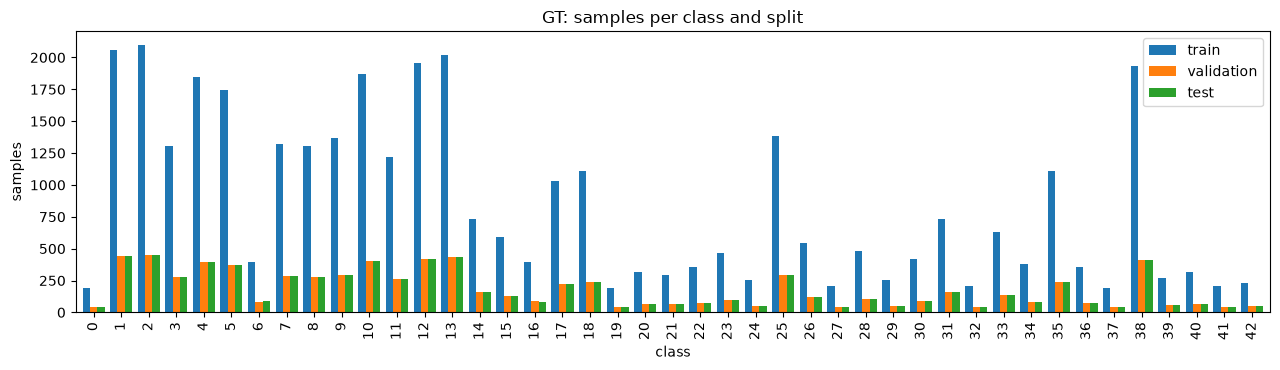

smallest class: 0 (189) | largest class: 2 (2100) | largest / smallest = 11.1


In [7]:
counts = pd.DataFrame({name: np.bincount(y_raw[idx], minlength=N_CLASSES) for name, idx in splits.items()},
                      index=CLASS_LABELS)
fig, ax = plt.subplots(figsize=(max(8, N_CLASSES * 0.3), 3.8))
counts.plot.bar(ax=ax, width=0.8)
ax.set_xlabel("class"); ax.set_ylabel("samples"); ax.set_title(f"{DATASET}: samples per class and split")
fig.tight_layout(); savefig(fig, f"{DATASET}_class_distribution"); plt.show()

train_counts = counts["train"]
print(f"smallest class: {train_counts.idxmin()} ({train_counts.min()}) | largest class: {train_counts.idxmax()} "
      f"({train_counts.max()}) | largest / smallest = {train_counts.max() / train_counts.min():.1f}")

**Samples.** One training image per class, titled `id: name`. Signs differ by **shape** (circle, triangle, octagon), **border color** and the **symbol** inside.

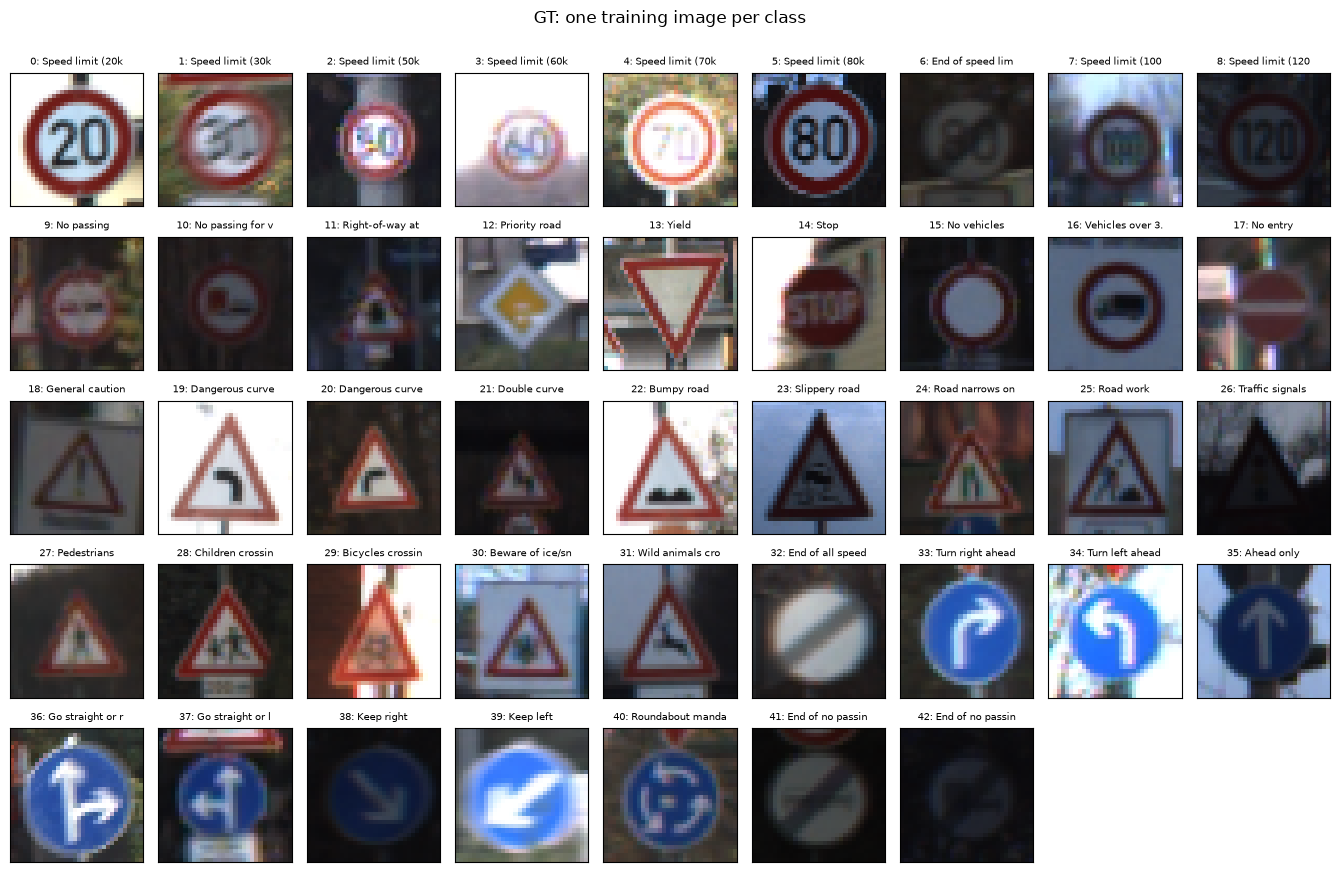

In [8]:
cols = 9
rows = int(np.ceil(N_CLASSES / cols))
fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.5, rows * 1.75))
rng = np.random.default_rng(SEED)
for c, ax in enumerate(axes.ravel()):
    ax.set_xticks([]); ax.set_yticks([])
    if c >= N_CLASSES:
        ax.axis("off")
        continue
    ax.imshow(X_train[rng.choice(np.where(y_train == c)[0])])
    ax.set_title(f"{c}: {CLASS_NAMES[c][:16]}", fontsize=7)
fig.suptitle(f"{DATASET}: one training image per class", y=1.0)
fig.tight_layout(); savefig(fig, f"{DATASET}_samples"); plt.show()

**Pixel values and brightness.** Many GTSRB photos are very dark (dusk, shadow). The brightness histogram shows how wide that spread is; BatchNorm (4.2) is one answer to it.

,mean,std
red,0.340,0.271
green,0.313,0.260
blue,0.323,0.268


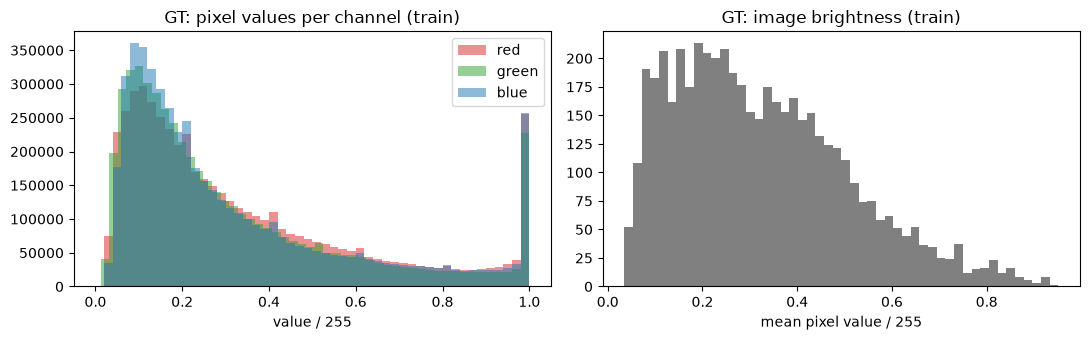

In [9]:
rng = np.random.default_rng(SEED)
sub = X_train[rng.choice(len(X_train), min(5000, len(X_train)), replace=False)].astype(np.float32) / 255.0
channel_names = ["red", "green", "blue"]
display(pd.DataFrame({"mean": sub.mean(axis=(0, 1, 2)), "std": sub.std(axis=(0, 1, 2))}, index=channel_names).round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ch, color in enumerate(["tab:red", "tab:green", "tab:blue"]):
    axes[0].hist(sub[..., ch].ravel(), bins=50, alpha=0.5, color=color, label=channel_names[ch])
axes[0].set_title(f"{DATASET}: pixel values per channel (train)"); axes[0].set_xlabel("value / 255"); axes[0].legend()
axes[1].hist(sub.mean(axis=(1, 2, 3)), bins=50, color="gray")
axes[1].set_title(f"{DATASET}: image brightness (train)"); axes[1].set_xlabel("mean pixel value / 255")
fig.tight_layout(); savefig(fig, f"{DATASET}_pixel_stats"); plt.show()

## 4. TensorFlow / Keras

### 4.1 Input pipeline

`tf.data`: shuffle (train only) → batch 256 → `/255` → prefetch. One batch: `(256, 32, 32, 3)` images, `(256,)` labels.

In [10]:
AUTOTUNE = tf.data.AUTOTUNE


def scale(x, y):
    return tf.cast(x, tf.float32) / 255.0, y


def make_tf_dataset(x, y, training):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if training:
        ds = ds.shuffle(len(x), seed=SEED, reshuffle_each_iteration=True)
    return ds.batch(BATCH_SIZE).map(scale, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)


train_ds = make_tf_dataset(X_train, y_train, training=True)
val_ds = make_tf_dataset(X_val, y_val, training=False)
test_ds = make_tf_dataset(X_test, y_test, training=False)
train_ds.element_spec

(TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name=None),
 TensorSpec(shape=(None,), dtype=tf.int64, name=None))

### 4.2 One conv block on a sign edge

A conv block is **Conv → BatchNorm → ReLU → MaxPool**. Example: the diagonal side of a triangular warning sign,
as a 5×5 patch (1 = sign, 0 = background), and a diagonal-edge filter:

```
patch          filter
1 0 0 0 0       0 -1 -1
1 1 0 0 0       1  0 -1
1 1 1 0 0       1  1  0
1 1 1 1 0
1 1 1 1 1
```

- **Convolution** `out = Σ (window × filter) + bias`:
  - window on the diagonal `[[1,0,0],[1,1,0],[1,1,1]]` → row sums `0 + 1 + 2 = 3`: strong response
  - window inside the sign (all 1s) → sum of the filter = `0`: no response
- **ReLU** `= max(0, x)`: keeps `3`, turns negatives into `0`.
- **MaxPool 2×2**: largest of 4 values, e.g. `[[3, 0], [3, 3]] → 3`. The edge is still "seen" at half the resolution.
- **BatchNorm** per channel over the batch: `(x − μ) / σ`, then `γ·x̂ + β`.
  A batch mixing dark and bright pixels `[0.05, 0.10, 0.80, 0.90]` (μ = 0.46, σ = 0.39) becomes
  `[−1.06, −0.93, 0.87, 1.12]`: the next layer always sees values around 0 with spread 1, whatever the lighting.

The cell repeats this with NumPy and checks against `tf.nn.conv2d`.

In [11]:
patch = np.tril(np.ones((5, 5), dtype=np.float32))                   # diagonal edge of a triangle
kernel = np.array([[0, -1, -1], [1, 0, -1], [1, 1, 0]], dtype=np.float32)

conv = np.array([[np.sum(patch[i:i + 3, j:j + 3] * kernel) for j in range(3)] for i in range(3)])
tf_conv = tf.nn.conv2d(patch[None, :, :, None], kernel[:, :, None, None], strides=1, padding="VALID")[0, :, :, 0]
print("convolution (by hand):\n", conv)
print("same as tf.nn.conv2d:", np.allclose(conv, tf_conv.numpy()))
print("ReLU:\n", np.maximum(0, conv))

batch = np.array([0.05, 0.10, 0.80, 0.90])
print("BatchNorm of", batch, "->", ((batch - batch.mean()) / np.sqrt(batch.var() + 1e-5)).round(2))

convolution (by hand):
 [[3. 3. 1.]
 [1. 3. 3.]
 [0. 1. 3.]]
same as tf.nn.conv2d: True
ReLU:
 [[3. 3. 1.]
 [1. 3. 3.]
 [0. 1. 3.]]
BatchNorm of [0.05 0.1  0.8  0.9 ] -> [-1.06 -0.93  0.87  1.12]


### 4.3 The CNN-3 model

This cell builds CNN-3: three conv blocks (Conv → BatchNorm → ReLU → MaxPool), then a small classifier head.

| Layer | Computation | Shape (one sign) |
|---|---|---|
| Input | pixels / 255 | 32×32×3 |
| Conv 3×3, 32 filters | each position: Σ(3×3×3 window × weights) + bias | 32×32×32 |
| BatchNorm | (x − μ)/σ · γ + β, e.g. [1, 3, 5] → [−1.22, 0, 1.22] | 32×32×32 |
| ReLU | max(0, x): −1.3 → 0, 0.8 → 0.8 | 32×32×32 |
| MaxPool 2×2 | largest of 4: [[0.1, 0.9], [0.4, 0.2]] → 0.9 | 16×16×32 |
| Blocks 2, 3 | same, with 64 then 128 filters | 8×8×64 → 4×4×128 |
| GAP | mean of each 4×4 map → one number | 128 |
| Dropout 0.3 | in training, 30% of values set to 0 | 128 |
| Dense 256 → Dense 43 | 43 scores (logits), one per sign class | 43 |

- `padding="same"` adds a zero border, so 32×32 stays 32×32 after each Conv.
- Conv parameters = (3·3·C_in + 1)·F, e.g. first layer (3·3·3 + 1)·32 = 896.
- **CNN-5** is the same, but blocks 1 and 2 have two Convs before the pool (32, 32 and 64, 64).
  Same output shapes; one final unit sees 28×28 input pixels instead of 22×22.

The next cell passes one real sign through every layer and prints each output shape.

In [12]:
ARCH = {  # (filters, max-pool after this conv?)
    "CNN-3": [(32, True), (64, True), (128, True)],
    "CNN-5": [(32, False), (32, True), (64, False), (64, True), (128, True)],
}
HEAD_UNITS = 256
DROPOUT = 0.3


def conv_block_tf(x, filters, pool):
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization(momentum=0.9, epsilon=1e-5)(x)
    x = layers.ReLU()(x)
    if pool:
        x = layers.MaxPooling2D(2)(x)
    return x


def build_tf(model_name, input_shape, n_classes):
    inputs = keras.Input(shape=input_shape)
    x = inputs
    for filters, pool in ARCH[model_name]:
        x = conv_block_tf(x, filters, pool)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(DROPOUT)(x)
    x = layers.Dense(HEAD_UNITS, activation="relu")(x)
    outputs = layers.Dense(n_classes)(x)            # logits
    return keras.Model(inputs, outputs, name=f"{DATASET}_TF_{model_name.replace('-', '')}")

In [13]:
image = X_train[:1].astype(np.float32) / 255.0          # one training image, batch of 1
for m in MODELS:
    model = build_tf(m, INPUT_SHAPE_TF, N_CLASSES)
    x, rows = image, []
    for layer in model.layers[1:]:
        x = layer(x, training=False)
        rows.append((layer.__class__.__name__, tuple(x.shape[1:]), layer.count_params()))
    print(f"{m}: one image through every layer")
    display(pd.DataFrame(rows, columns=["layer", "output shape", "params"]).T)

CNN-3: one image through every layer


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
layer,Conv2D,BatchNormalization,ReLU,MaxPooling2D,Conv2D,BatchNormalization,ReLU,MaxPooling2D,Conv2D,BatchNormalization,ReLU,MaxPooling2D,GlobalAveragePooling2D,Dropout,Dense,Dense
output shape,"(32, 32, 32)","(32, 32, 32)","(32, 32, 32)","(16, 16, 32)","(16, 16, 64)","(16, 16, 64)","(16, 16, 64)","(8, 8, 64)","(8, 8, 128)","(8, 8, 128)","(8, 8, 128)","(4, 4, 128)","(128,)","(128,)","(256,)","(43,)"
params,896,128,0,0,18496,256,0,0,73856,512,0,0,0,0,33024,11051


CNN-5: one image through every layer


,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
layer,Conv2D,BatchNormalization,ReLU,Conv2D,BatchNormalization,ReLU,MaxPooling2D,Conv2D,BatchNormalization,ReLU,...,ReLU,MaxPooling2D,Conv2D,BatchNormalization,ReLU,MaxPooling2D,GlobalAveragePooling2D,Dropout,Dense,Dense
output shape,"(32, 32, 32)","(32, 32, 32)","(32, 32, 32)","(32, 32, 32)","(32, 32, 32)","(32, 32, 32)","(16, 16, 32)","(16, 16, 64)","(16, 16, 64)","(16, 16, 64)",...,"(16, 16, 64)","(8, 8, 64)","(8, 8, 128)","(8, 8, 128)","(8, 8, 128)","(4, 4, 128)","(128,)","(128,)","(256,)","(43,)"
params,896,128,0,9248,128,0,0,18496,256,0,...,0,0,73856,512,0,0,0,0,33024,11051


### 4.4 Parameters

- Conv: `(K·K·C_in + 1)·F`, e.g. first layer `(3·3·3 + 1)·32 = 896`.
- BatchNorm: `2·F` trainable (γ, β).
- Dense: `(inputs + 1)·units`. The 43-class output alone has `(256 + 1)·43 = 11,051`.
- Pooling, ReLU, dropout: none.

The PyTorch models must match these totals (section 5).

In [14]:
def expected_params(model_name, in_channels, n_classes):
    rows, c = [], in_channels
    for i, (f, _) in enumerate(ARCH[model_name], start=1):
        rows.append((f"conv{i}", f"(3·3·{c} + 1)·{f}", (9 * c + 1) * f))
        rows.append((f"bn{i}", f"2·{f}", 2 * f))
        c = f
    rows.append(("dense", f"({c} + 1)·{HEAD_UNITS}", (c + 1) * HEAD_UNITS))
    rows.append(("output", f"({HEAD_UNITS} + 1)·{n_classes}", (HEAD_UNITS + 1) * n_classes))
    return pd.DataFrame(rows, columns=["layer", "formula", "params"])


def trainable_params_tf(model):
    return int(sum(np.prod(w.shape) for w in model.trainable_weights))


for m in MODELS:
    table = expected_params(m, INPUT_CHANNELS, N_CLASSES)
    print(f"{m}: {table.params.sum():,} trainable parameters")
    display(table.set_index("layer").T)

CNN-3: 137,771 trainable parameters

layer,conv1,bn1,conv2,bn2,conv3,bn3,dense,output
formula,(3·3·3 + 1)·32,2·32,(3·3·32 + 1)·64,2·64,(3·3·64 + 1)·128,2·128,(128 + 1)·256,(256 + 1)·43
params,896,64,18496,128,73856,256,33024,11051


CNN-5: 184,139 trainable parameters


layer,conv1,bn1,conv2,bn2,conv3,bn3,conv4,bn4,conv5,bn5,dense,output
formula,(3·3·3 + 1)·32,2·32,(3·3·32 + 1)·32,2·32,(3·3·32 + 1)·64,2·64,(3·3·64 + 1)·64,2·64,(3·3·64 + 1)·128,2·128,(128 + 1)·256,(256 + 1)·43
params,896,64,9248,64,18496,128,36928,128,73856,256,33024,11051


### 4.5 Loss and training

This cell compiles and trains the model with early stopping.

| Part | Computation | Example |
|---|---|---|
| Softmax | p_k = e^(z_k) / Σ e^(z_j) | 43 probabilities summing to 1 |
| Cross-entropy | L = −ln p(true class) | p = 0.95 → 0.05; p = 0.01 → 4.6 |
| Start of training | all p = 1/43 | L = ln 43 = 3.76 |
| Adam | w ← w − 0.001 · m / (√v + ε) | each weight gets its own step size |
| Epoch | all training batches of 256 once | ≈ 142 updates |
| Early stopping | stop after 3 epochs with no lower validation loss | keep the best epoch's weights |

- `from_logits=True`: softmax is applied inside the loss (more stable).
- Time per epoch = median of epochs 2+ (epoch 1 also builds the graph).
- **Progress:** a bar inside each epoch (Keras bar / `tqdm` in PyTorch) shows the time left for that epoch. After each epoch:
  `time left ≈ median epoch time × epochs left`, e.g. 30 s × 17 = 8.5 min. It is an upper bound, since early stopping usually ends sooner.

In [15]:
class EpochTimer(keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.times = []

    def on_epoch_begin(self, epoch, logs=None):
        self._start = time.perf_counter()

    def on_epoch_end(self, epoch, logs=None):
        self.times.append(time.perf_counter() - self._start)


def train_tf(model):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE, epsilon=1e-7),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"],
    )
    timer = EpochTimer()
    stopper = keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=[stopper, timer], verbose=2)
    hist = {k: [float(v) for v in vals] for k, vals in history.history.items()}
    return hist, timer.times, int(np.argmin(hist["val_loss"])) + 1

### 4.6 Test metrics: why macro F1

Per class: **precision** = TP / (TP + FP), **recall** = TP / (TP + FN), **F1** = 2PR / (P + R).
**Macro F1** = plain mean of the 43 F1 scores.

Toy example with an unbalanced test set: 95 "speed limit" images and 5 "rare sign" images. A model that always
answers "speed limit" gets **accuracy 0.95** but **macro F1 0.49** (F1 = 0.97 for the big class, 0 for the rare one).
The cell below computes it. On GTSRB, macro F1 shows whether rare signs are recognized too.

In [16]:
from sklearn.metrics import accuracy_score, f1_score

toy_true = np.array([0] * 95 + [1] * 5)
toy_pred = np.zeros(100, dtype=int)                       # always predicts the big class
print("accuracy:", accuracy_score(toy_true, toy_pred),
      "| per-class F1:", f1_score(toy_true, toy_pred, average=None, zero_division=0).round(3),
      "| macro F1:", round(f1_score(toy_true, toy_pred, average="macro", zero_division=0), 3))

accuracy: 0.95 | per-class F1: [0.974 0.   ] | macro F1: 0.487


In [17]:
def evaluate_tf(model):
    model.predict(test_ds.take(1), verbose=0)           # warm-up, not timed
    with Stopwatch() as t:
        logits = model.predict(test_ds, verbose=0)
    probs = tf.nn.softmax(logits).numpy()
    y_pred = probs.argmax(axis=1)
    return y_pred, probs, classification_metrics(y_test, y_pred), 1000 * t.seconds / len(y_test)


def make_record(run_id, framework, model_name, params, hist, epoch_times, best_epoch, metrics, ms_per_1k):
    return {
        "run_id": run_id, "dataset": DATASET, "framework": framework, "model": model_name,
        "params": params, "epochs_run": len(epoch_times), "best_epoch": best_epoch,
        "train_time_s": float(sum(epoch_times)),
        # epoch 1 includes one-time setup (graph tracing, GPU kernel loading): excluded here
        "time_per_epoch_s": float(np.median(epoch_times[1:] if len(epoch_times) > 1 else epoch_times)),
        "inference_ms_per_1k": float(ms_per_1k), "test_metrics": metrics,
        "history": {k: hist[k] for k in ("loss", "val_loss", "accuracy", "val_accuracy")},
        "smoke": SMOKE,
    }


def run_tf(model_name):
    run_id = f"{DATASET}-TF-{model_name}"
    keras.utils.set_random_seed(SEED)                 # same initial weights on every rerun
    model = build_tf(model_name, INPUT_SHAPE_TF, N_CLASSES)
    params = trainable_params_tf(model)
    assert params == expected_params(model_name, INPUT_CHANNELS, N_CLASSES).params.sum()
    model.summary()
    hist, epoch_times, best_epoch = train_tf(model)
    y_pred, probs, metrics, ms_per_1k = evaluate_tf(model)
    record = make_record(run_id, "TF", model_name, params, hist, epoch_times, best_epoch, metrics, ms_per_1k)
    save_result(record)
    model.save(MODELS_DIR / f"{run_id}.keras")
    print(pd.Series(metrics).round(4).to_string())
    plot_history(record["history"], run_id)
    plot_confusion(y_test, y_pred, CLASS_LABELS, run_id)
    return model, y_pred, record

### 4.7 `GT-TF-CNN-3`
Build → check parameters → train → test → save `results/GT-TF-CNN-3.json` → curves and 43×43 confusion matrix (row = true sign, column = predicted).

Model: "GT_TF_CNN3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_8 (ReLU)                       │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_9 (ReLU)                       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 8, 8, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_10 (ReLU)                      │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 256)                 │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 43)                  │          11,051 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 138,219 (539.92 KB)

 Trainable params: 137,771 (538.17 KB)

 Non-trainable params: 448 (1.75 KB)

...

Epoch 19/20


142/142 - 24s - 166ms/step - accuracy: 0.9680 - loss: 0.1066 - val_accuracy: 0.9651 - val_loss: 0.1132


Epoch 20/20


142/142 - 24s - 168ms/step - accuracy: 0.9729 - loss: 0.0943 - val_accuracy: 0.9706 - val_loss: 0.0937


accuracy           0.9781
precision_macro    0.9779
recall_macro       0.9740
f1_macro           0.9751


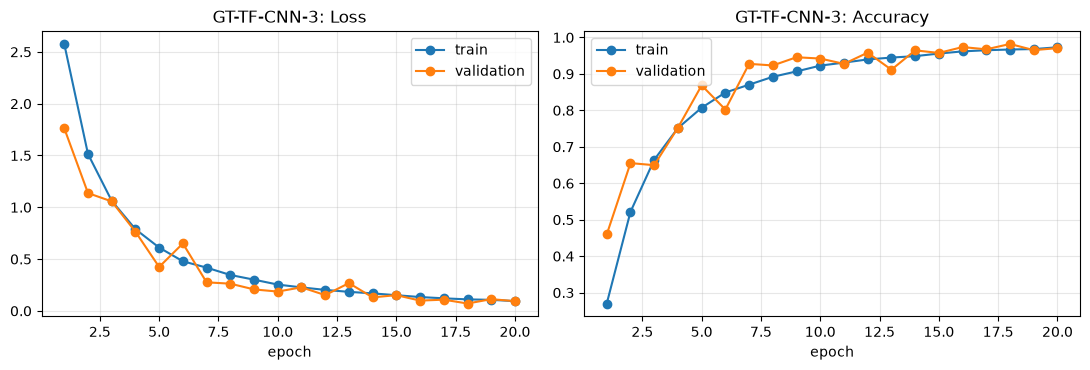

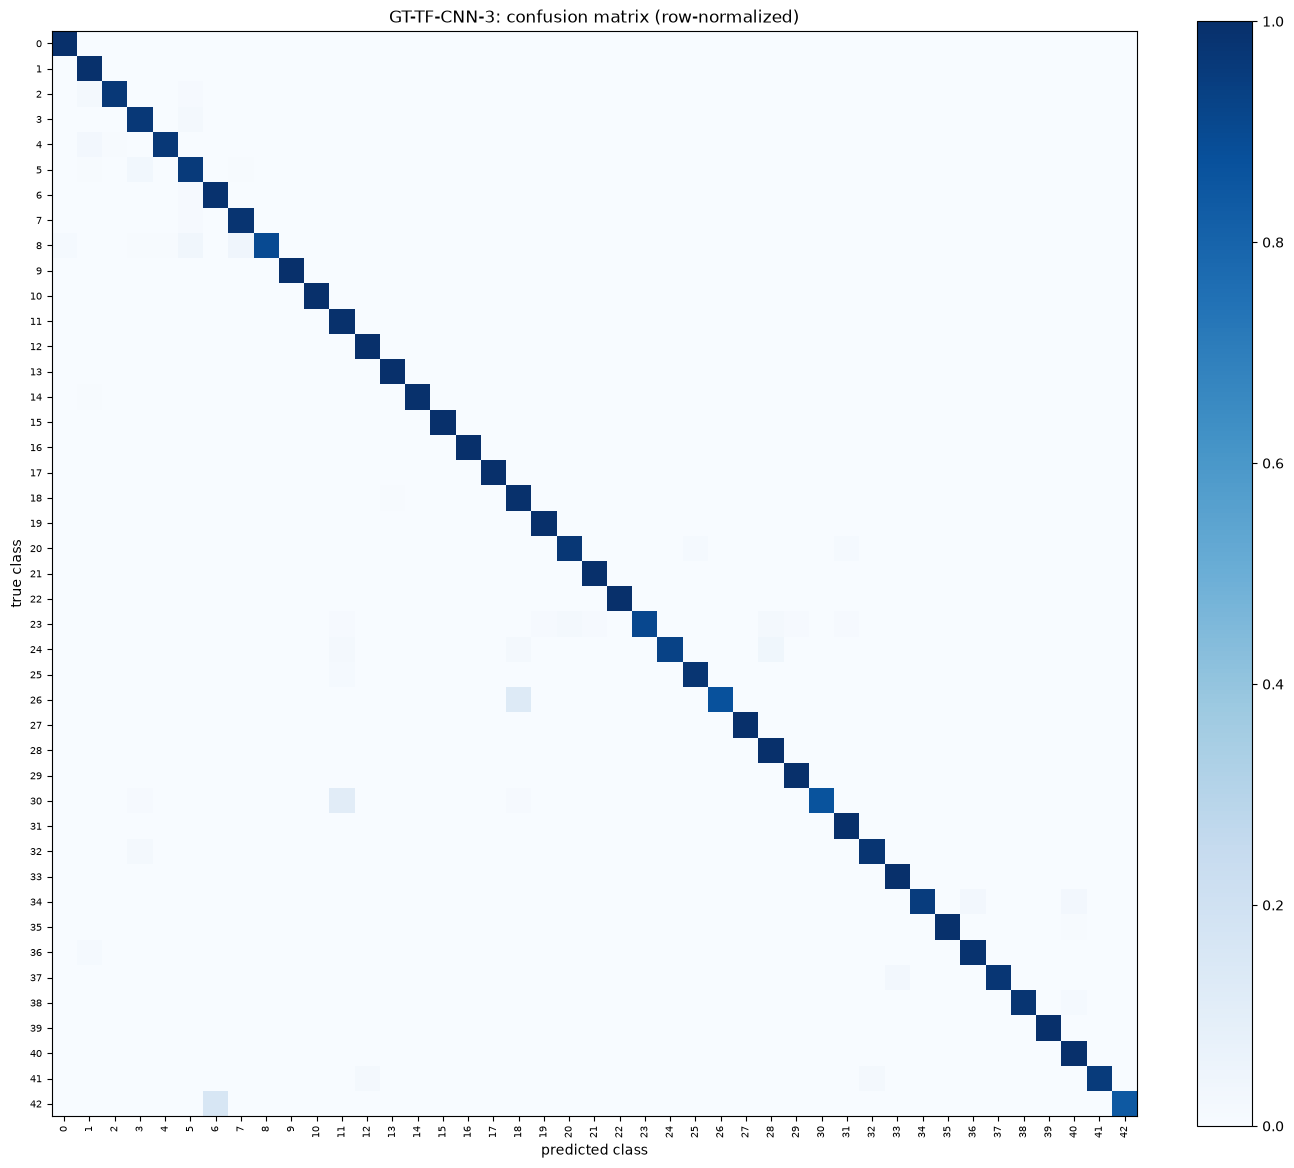

In [18]:
tf_models, tf_preds = {}, {}
tf_models["CNN-3"], tf_preds["CNN-3"], _ = run_tf("CNN-3")

### 4.8 `GT-TF-CNN-5`

Model: "GT_TF_CNN5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_11 (ReLU)                      │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 32, 32, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_12 (ReLU)                      │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_13 (ReLU)                      │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 16, 16, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_14               │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_14 (ReLU)                      │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_15               │ (None, 8, 8, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_15 (ReLU)                      │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 4, 4, 128)           │              

 Total params: 184,779 (721.79 KB)

 Trainable params: 184,139 (719.29 KB)

 Non-trainable params: 640 (2.50 KB)

...

Epoch 10/20


142/142 - 45s - 318ms/step - accuracy: 0.9942 - loss: 0.0226 - val_accuracy: 0.9825 - val_loss: 0.0547


Epoch 11/20


142/142 - 45s - 317ms/step - accuracy: 0.9939 - loss: 0.0214 - val_accuracy: 0.9659 - val_loss: 0.1141


accuracy           0.9911
precision_macro    0.9921
recall_macro       0.9895
f1_macro           0.9907


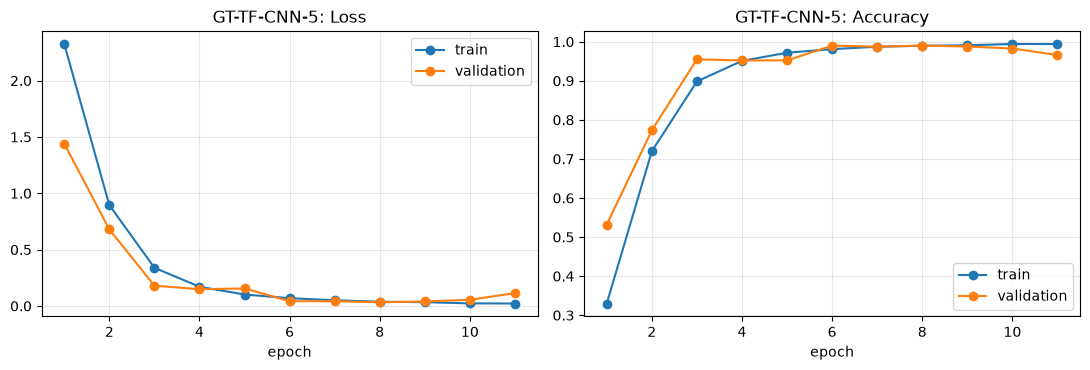

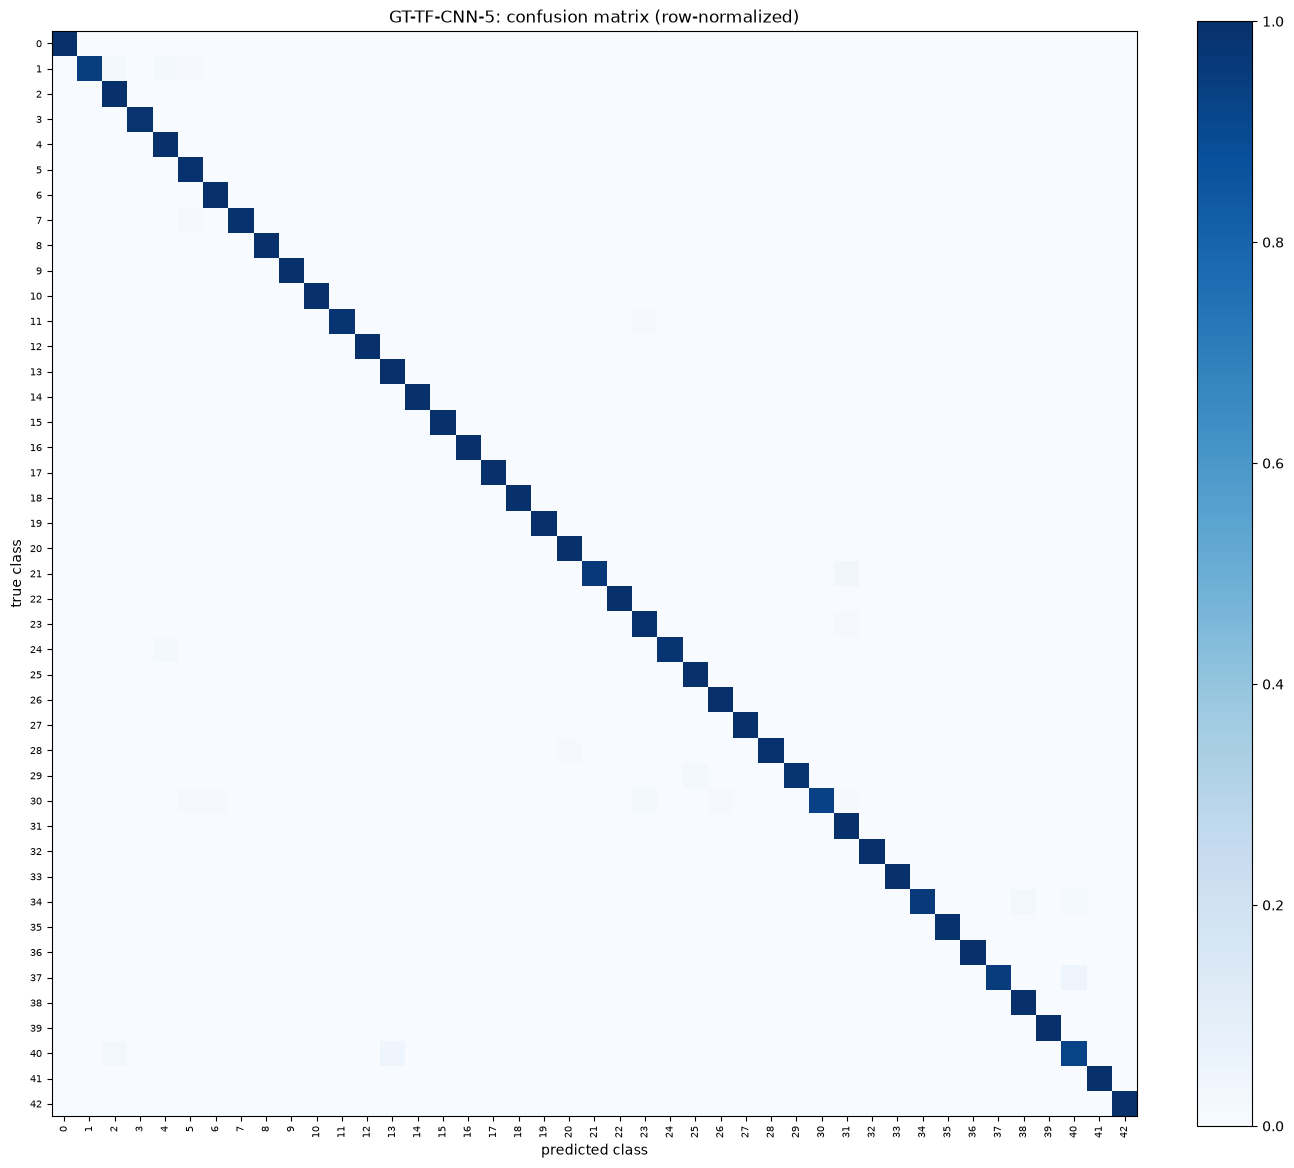

In [19]:
tf_models["CNN-5"], tf_preds["CNN-5"], _ = run_tf("CNN-5")

### 4.9 What the first layer learned

- **Filters:** the 32 first-layer filters (3×3×3), drawn as tiny color images. Red/white contrast filters are
  typical for sign borders.
- **Feature maps:** each filter's output after ReLU for one test sign; bright = strong response.

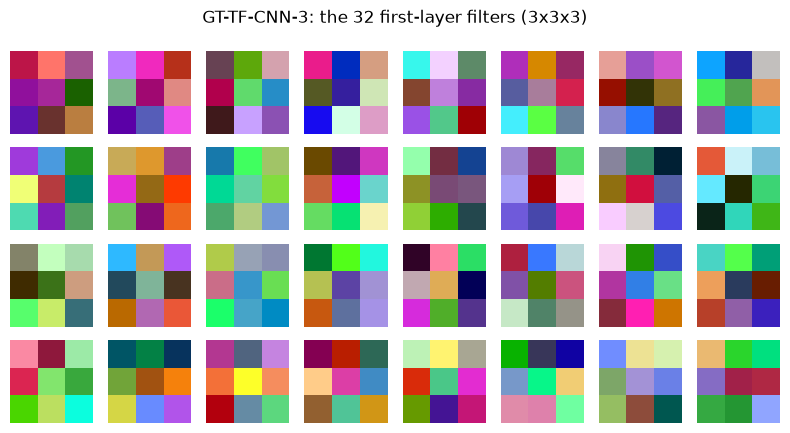

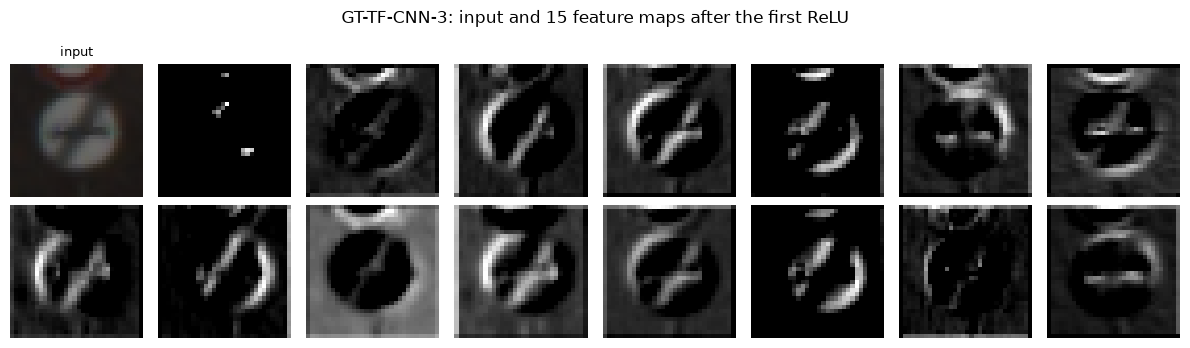

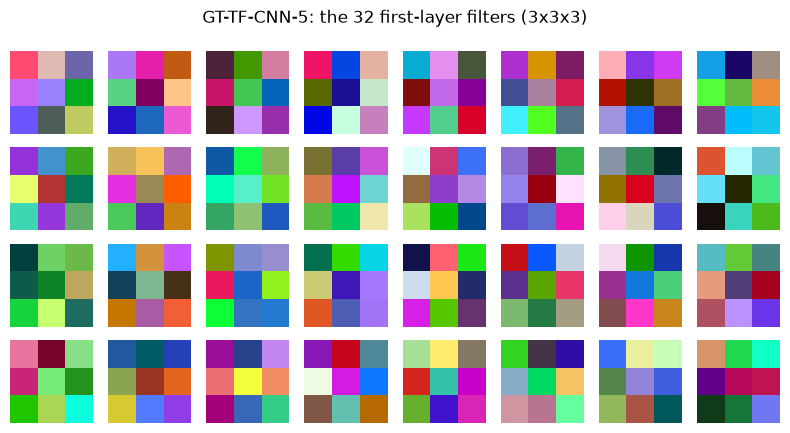

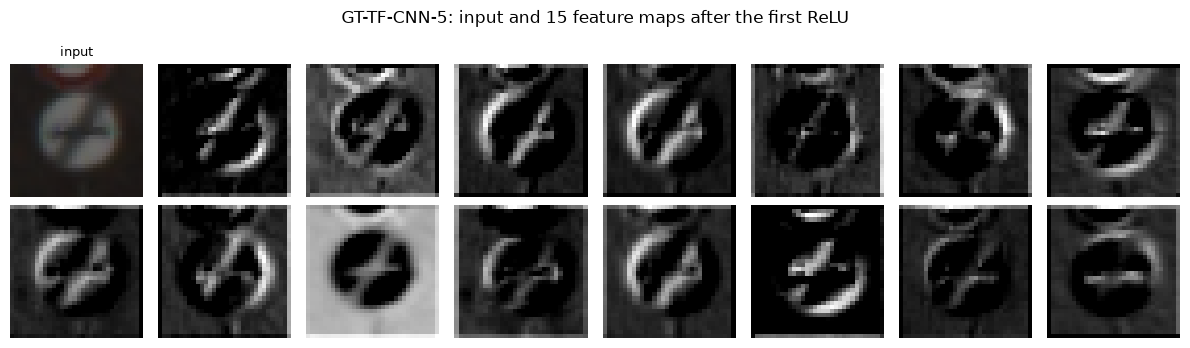

In [20]:
sample = X_test[:1].astype(np.float32) / 255.0          # one test image


def show_filters(filters, run_id):
    """filters: (F, K, K, C_in). Each filter is min-max scaled and drawn as a 3x3 color image."""
    fig, axes = plt.subplots(4, 8, figsize=(8, 4.4))
    for ax in axes.ravel():
        ax.axis("off")
    for ax, f in zip(axes.ravel(), filters):
        ax.imshow((f - f.min()) / (f.max() - f.min() + 1e-8))
    fig.suptitle(f"{run_id}: the 32 first-layer filters (3x3x3)")
    fig.tight_layout(); savefig(fig, f"{run_id}_filters"); plt.show()


def show_feature_maps(maps, run_id):
    """maps: (F, H, W) after the first ReLU. First panel = the input image."""
    fig, axes = plt.subplots(2, 8, figsize=(12, 3.6))
    for ax in axes.ravel():
        ax.axis("off")
    axes[0, 0].imshow(sample[0]); axes[0, 0].set_title("input", fontsize=9)
    for ax, fm in zip(axes.ravel()[1:], maps):
        ax.imshow(fm, cmap="gray")
    fig.suptitle(f"{run_id}: input and 15 feature maps after the first ReLU")
    fig.tight_layout(); savefig(fig, f"{run_id}_feature_maps"); plt.show()


def tf_filters(m):
    conv = next(l for l in tf_models[m].layers if isinstance(l, layers.Conv2D))
    return np.transpose(conv.get_weights()[0], (3, 0, 1, 2))            # (K, K, C_in, F) -> (F, K, K, C_in)


def tf_maps(m):
    model = tf_models[m]
    relu = next(l for l in model.layers if isinstance(l, layers.ReLU))
    return np.transpose(keras.Model(model.inputs, relu.output)(sample).numpy()[0], (2, 0, 1))


for m in MODELS:
    show_filters(tf_filters(m), f"{DATASET}-TF-{m}")
    show_feature_maps(tf_maps(m), f"{DATASET}-TF-{m}")

### 4.10 Errors
Test signs CNN-5 got wrong (true / predicted class id; names in the table in 2.1).

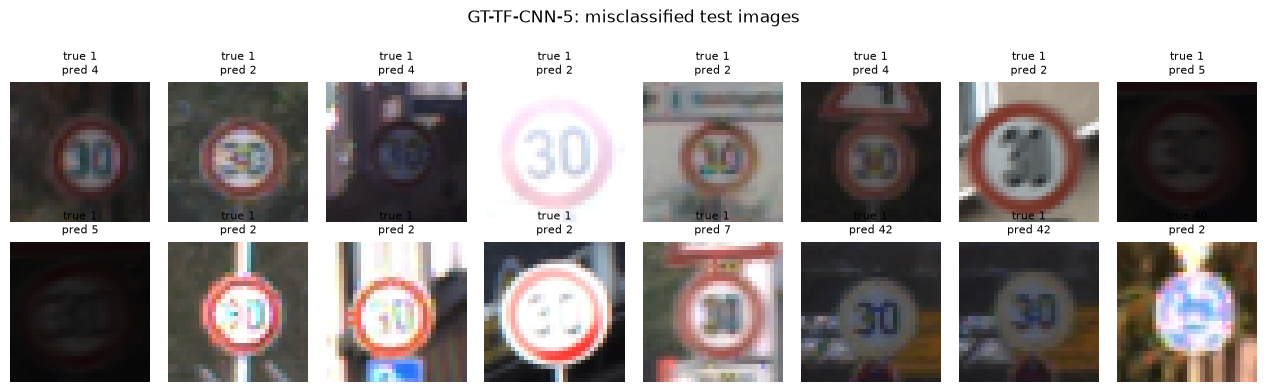

In [21]:
def show_misclassified(y_pred, run_id, n=16):
    wrong = np.where(y_pred != y_test)[0][:n]
    cols = 8
    rows = max(1, int(np.ceil(len(wrong) / cols)))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.6, rows * 1.9), squeeze=False)
    for ax in axes.ravel():
        ax.axis("off")
    for ax, i in zip(axes.ravel(), wrong):
        ax.imshow(X_test[i])
        ax.set_title(f"true {CLASS_LABELS[y_test[i]]}\npred {CLASS_LABELS[y_pred[i]]}", fontsize=8)
    fig.suptitle(f"{run_id}: misclassified test images", y=1.02)
    fig.tight_layout(); savefig(fig, f"{run_id}_misclassified"); plt.show()


show_misclassified(tf_preds["CNN-5"], f"{DATASET}-TF-CNN-5")

## 5. PyTorch

Same models, data and settings, written differently:

| Step | Keras | PyTorch |
|---|---|---|
| data | `tf.data` | `TensorDataset` + `DataLoader` |
| layout | `(N, 32, 32, 3)` | `(N, 3, 32, 32)` |
| conv | `Conv2D(32, 3, padding="same")` | `Conv2d(3, 32, 3, padding=1)` (input channels explicit) |
| output | `Dense(43)` | `Linear(256, 43)` (input size explicit) |
| initial weights | Glorot uniform | `xavier_uniform_` (= Glorot), set by hand |
| BatchNorm momentum | 0.9 (old value) | 0.1 (new value): same update |
| training | `fit` | hand-written loop |

### 5.1 Data loader

In [22]:
from torch.utils.data import DataLoader, TensorDataset


def make_loader(x, y, training):
    ds = TensorDataset(torch.from_numpy(x), torch.from_numpy(y))
    g = torch.Generator().manual_seed(SEED)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=training, generator=g if training else None)


train_loader = make_loader(X_train_pt, y_train, training=True)
val_loader = make_loader(X_val_pt, y_val, training=False)
test_loader = make_loader(X_test_pt, y_test, training=False)


def to_device(x):
    return x.to(DEVICE).float() / 255.0


xb, yb = next(iter(train_loader))
print("batch:", tuple(xb.shape), xb.dtype, "| labels:", tuple(yb.shape))

batch: (256, 3, 32, 32) torch.uint8 | labels: (256,)


### 5.2 Model class
`__init__` creates the layers, `forward` runs them. The check below confirms the same parameter count as Keras.

In [23]:
def init_like_keras(module):
    if isinstance(module, (nn.Conv2d, nn.Linear)):
        nn.init.xavier_uniform_(module.weight)
        nn.init.zeros_(module.bias)


class CNN(nn.Module):
    def __init__(self, model_name, in_channels, n_classes):
        super().__init__()
        blocks, c = [], in_channels
        for filters, pool in ARCH[model_name]:
            blocks += [nn.Conv2d(c, filters, kernel_size=3, padding=1),
                       nn.BatchNorm2d(filters, momentum=0.1, eps=1e-5),
                       nn.ReLU()]
            if pool:
                blocks.append(nn.MaxPool2d(2))
            c = filters
        self.features = nn.Sequential(*blocks)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Dropout(DROPOUT),
            nn.Linear(c, HEAD_UNITS), nn.ReLU(),
            nn.Linear(HEAD_UNITS, n_classes),       # logits
        )
        self.apply(init_like_keras)

    def forward(self, x):
        return self.head(self.features(x))


def trainable_params_pt(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


for m in MODELS:
    n_pt = trainable_params_pt(CNN(m, INPUT_CHANNELS, N_CLASSES))
    n_formula = expected_params(m, INPUT_CHANNELS, N_CLASSES).params.sum()
    assert n_pt == n_formula, (m, n_pt, n_formula)
    print(f"{m}: PyTorch {n_pt:,} = formula {n_formula:,} = Keras (match)")

CNN-3: PyTorch 137,771 = formula 137,771 = Keras (match)
CNN-5: PyTorch 184,139 = formula 184,139 = Keras (match)


### 5.3 Training loop

Per batch: `zero_grad()` (clear gradients) → `model(x)` (forward, `(256, 3, 32, 32) → (256, 43)`) →
`CrossEntropyLoss` (same formula as 4.5) → `backward()` (gradients) → `step()` (Adam update).

`model.train()` = dropout on, BatchNorm uses batch statistics. `model.eval()` + `no_grad()` = dropout off,
BatchNorm uses running statistics, no gradients. Early stopping is a counter: 3 epochs without improvement → stop,
reload the best weights.

In [24]:
def sync():
    if DEVICE.type == "mps":
        torch.mps.synchronize()
    elif DEVICE.type == "cuda":
        torch.cuda.synchronize()


@torch.no_grad()
def evaluate_loader(model, loader, criterion):
    model.eval()
    total_loss, correct, n, logits_all = 0.0, 0, 0, []
    for x, y in loader:
        x, y = to_device(x), y.to(DEVICE)
        logits = model(x)
        total_loss += criterion(logits, y).item() * len(y)
        correct += (logits.argmax(1) == y).sum().item()
        n += len(y)
        logits_all.append(logits.cpu())
    return total_loss / n, correct / n, torch.cat(logits_all)


def train_pt(model):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, eps=1e-7)
    hist = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}
    epoch_times, best_loss, best_state, wait = [], float("inf"), None, 0

    for epoch in range(1, EPOCHS + 1):
        sync(); start = time.perf_counter()
        model.train()
        total_loss, correct, n = 0.0, 0, 0
        for x, y in train_loader:
            x, y = to_device(x), y.to(DEVICE)
            optimizer.zero_grad()              # 1. clear old gradients
            logits = model(x)                  # 2. forward pass
            loss = criterion(logits, y)        # 3. loss
            loss.backward()                    # 4. backpropagation
            optimizer.step()                   # 5. Adam update
            total_loss += loss.item() * len(y)
            correct += (logits.argmax(1) == y).sum().item()
            n += len(y)
        val_loss, val_acc, _ = evaluate_loader(model, val_loader, criterion)
        sync(); epoch_times.append(time.perf_counter() - start)

        for k, v in zip(hist, (total_loss / n, correct / n, val_loss, val_acc)):
            hist[k].append(float(v))
        print(f"Epoch {epoch}/{EPOCHS} - {epoch_times[-1]:.1f}s - loss: {hist['loss'][-1]:.4f} - "
              f"accuracy: {hist['accuracy'][-1]:.4f} - val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}")

        if val_loss < best_loss:               # early stopping, written by hand
            best_loss, best_state, wait = val_loss, copy.deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if wait >= PATIENCE:
                print(f"Epoch {epoch}: early stopping")
                break

    model.load_state_dict(best_state)
    best_epoch = int(np.argmin(hist["val_loss"])) + 1
    print(f"Restoring model weights from the end of the best epoch: {best_epoch}.")
    return hist, epoch_times, best_epoch


def evaluate_pt(model):
    criterion = nn.CrossEntropyLoss()
    evaluate_loader(model, [next(iter(test_loader))], criterion)       # warm-up
    sync()
    with Stopwatch() as t:
        _, _, logits = evaluate_loader(model, test_loader, criterion)
        sync()
    probs = torch.softmax(logits, dim=1).numpy()
    y_pred = probs.argmax(axis=1)
    return y_pred, probs, classification_metrics(y_test, y_pred), 1000 * t.seconds / len(y_test)


def run_pt(model_name):
    run_id = f"{DATASET}-PT-{model_name}"
    torch.manual_seed(SEED)
    model = CNN(model_name, INPUT_CHANNELS, N_CLASSES).to(DEVICE)
    params = trainable_params_pt(model)
    print(model)
    print(f"trainable parameters: {params:,}")
    hist, epoch_times, best_epoch = train_pt(model)
    y_pred, probs, metrics, ms_per_1k = evaluate_pt(model)
    record = make_record(run_id, "PT", model_name, params, hist, epoch_times, best_epoch, metrics, ms_per_1k)
    save_result(record)
    torch.save(model.state_dict(), MODELS_DIR / f"{run_id}.pt")
    print(pd.Series(metrics).round(4).to_string())
    plot_history(record["history"], run_id)
    plot_confusion(y_test, y_pred, CLASS_LABELS, run_id)
    return model, y_pred, record

### 5.4 `GT-PT-CNN-3`

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (head): Sequential(
    (0): AdaptiveAvgPool2d(output_size=1)
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Dropout(p=0.3, inplace

Epoch 1/20 - 25.2s - loss: 2.6514 - accuracy: 0.2588 - val_loss: 1.8560 - val_accuracy: 0.4039


Epoch 2/20 - 26.1s - loss: 1.5876 - accuracy: 0.5004 - val_loss: 1.1824 - val_accuracy: 0.6470


Epoch 3/20 - 26.2s - loss: 1.1293 - accuracy: 0.6398 - val_loss: 0.9120 - val_accuracy: 0.7024


Epoch 4/20 - 26.0s - loss: 0.8541 - accuracy: 0.7296 - val_loss: 0.6228 - val_accuracy: 0.8074


...

Epoch 17/20 - 25.5s - loss: 0.1317 - accuracy: 0.9608 - val_loss: 0.1022 - val_accuracy: 0.9704


Epoch 18/20 - 26.9s - loss: 0.1195 - accuracy: 0.9650 - val_loss: 0.1240 - val_accuracy: 0.9644


Epoch 19/20 - 26.2s - loss: 0.1126 - accuracy: 0.9672 - val_loss: 0.1455 - val_accuracy: 0.9574


Epoch 20/20 - 25.8s - loss: 0.0927 - accuracy: 0.9737 - val_loss: 0.0668 - val_accuracy: 0.9846
Restoring model weights from the end of the best epoch: 20.


accuracy           0.9848
precision_macro    0.9842
recall_macro       0.9849
f1_macro           0.9843


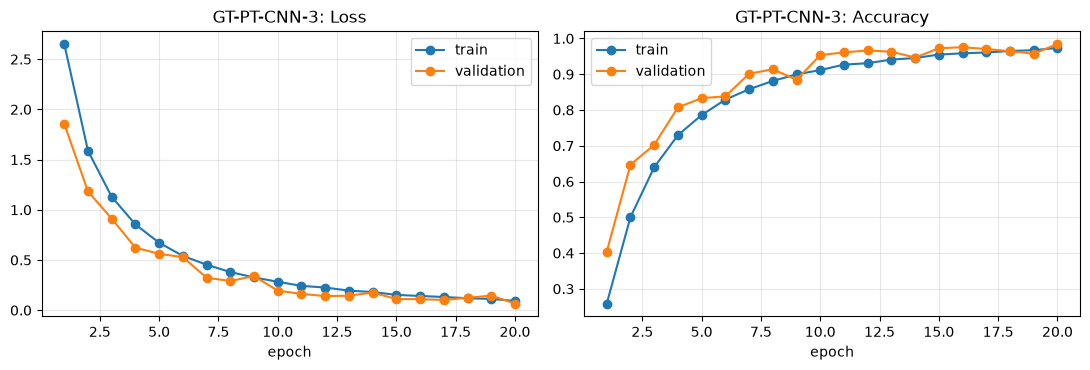

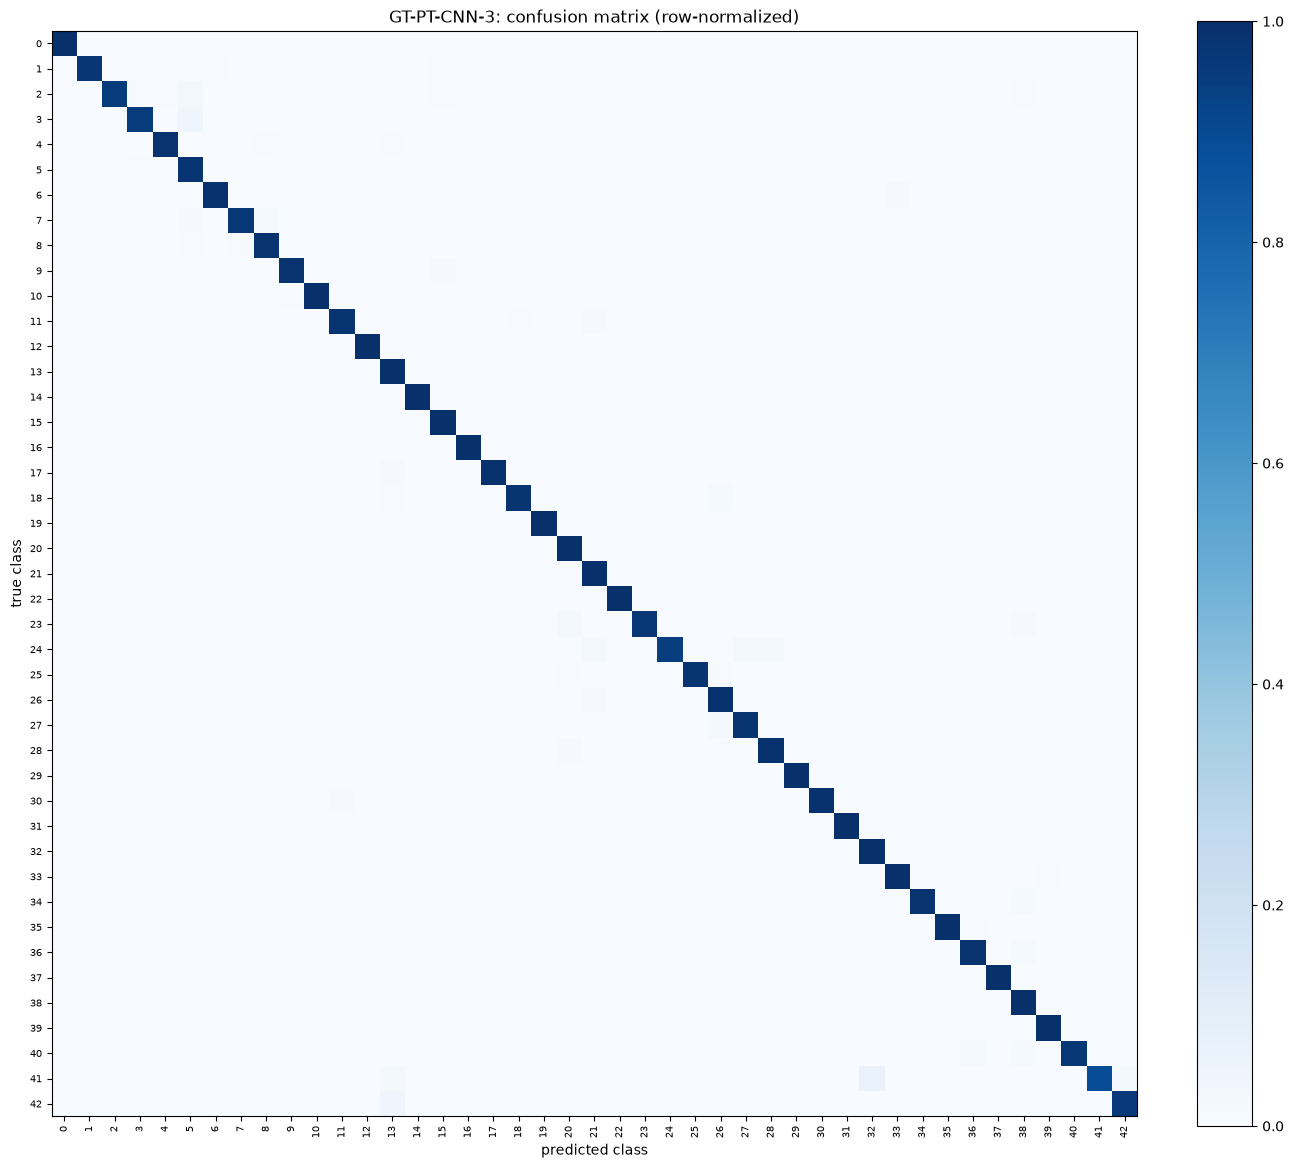

In [25]:
pt_models, pt_preds = {}, {}
pt_models["CNN-3"], pt_preds["CNN-3"], _ = run_pt("CNN-3")

### 5.5 `GT-PT-CNN-5`

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128, kernel_s

Epoch 1/20 - 52.2s - loss: 2.3779 - accuracy: 0.3112 - val_loss: 1.6088 - val_accuracy: 0.4738


Epoch 2/20 - 52.6s - loss: 0.9617 - accuracy: 0.6961 - val_loss: 0.6648 - val_accuracy: 0.7935


Epoch 3/20 - 52.8s - loss: 0.3802 - accuracy: 0.8847 - val_loss: 0.2707 - val_accuracy: 0.9230


Epoch 4/20 - 53.2s - loss: 0.1856 - accuracy: 0.9456 - val_loss: 0.1363 - val_accuracy: 0.9641


...

Epoch 13/20 - 53.7s - loss: 0.0146 - accuracy: 0.9963 - val_loss: 0.0179 - val_accuracy: 0.9942


Epoch 14/20 - 53.5s - loss: 0.0156 - accuracy: 0.9958 - val_loss: 0.0299 - val_accuracy: 0.9898


Epoch 15/20 - 53.2s - loss: 0.0195 - accuracy: 0.9944 - val_loss: 0.0264 - val_accuracy: 0.9924


Epoch 16/20 - 52.4s - loss: 0.0176 - accuracy: 0.9950 - val_loss: 0.0277 - val_accuracy: 0.9915
Epoch 16: early stopping
Restoring model weights from the end of the best epoch: 13.


accuracy           0.9943
precision_macro    0.9948
recall_macro       0.9927
f1_macro           0.9937


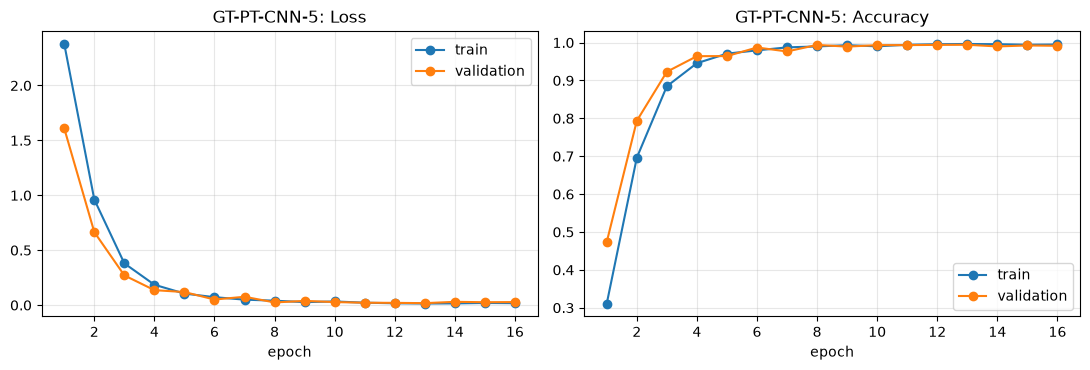

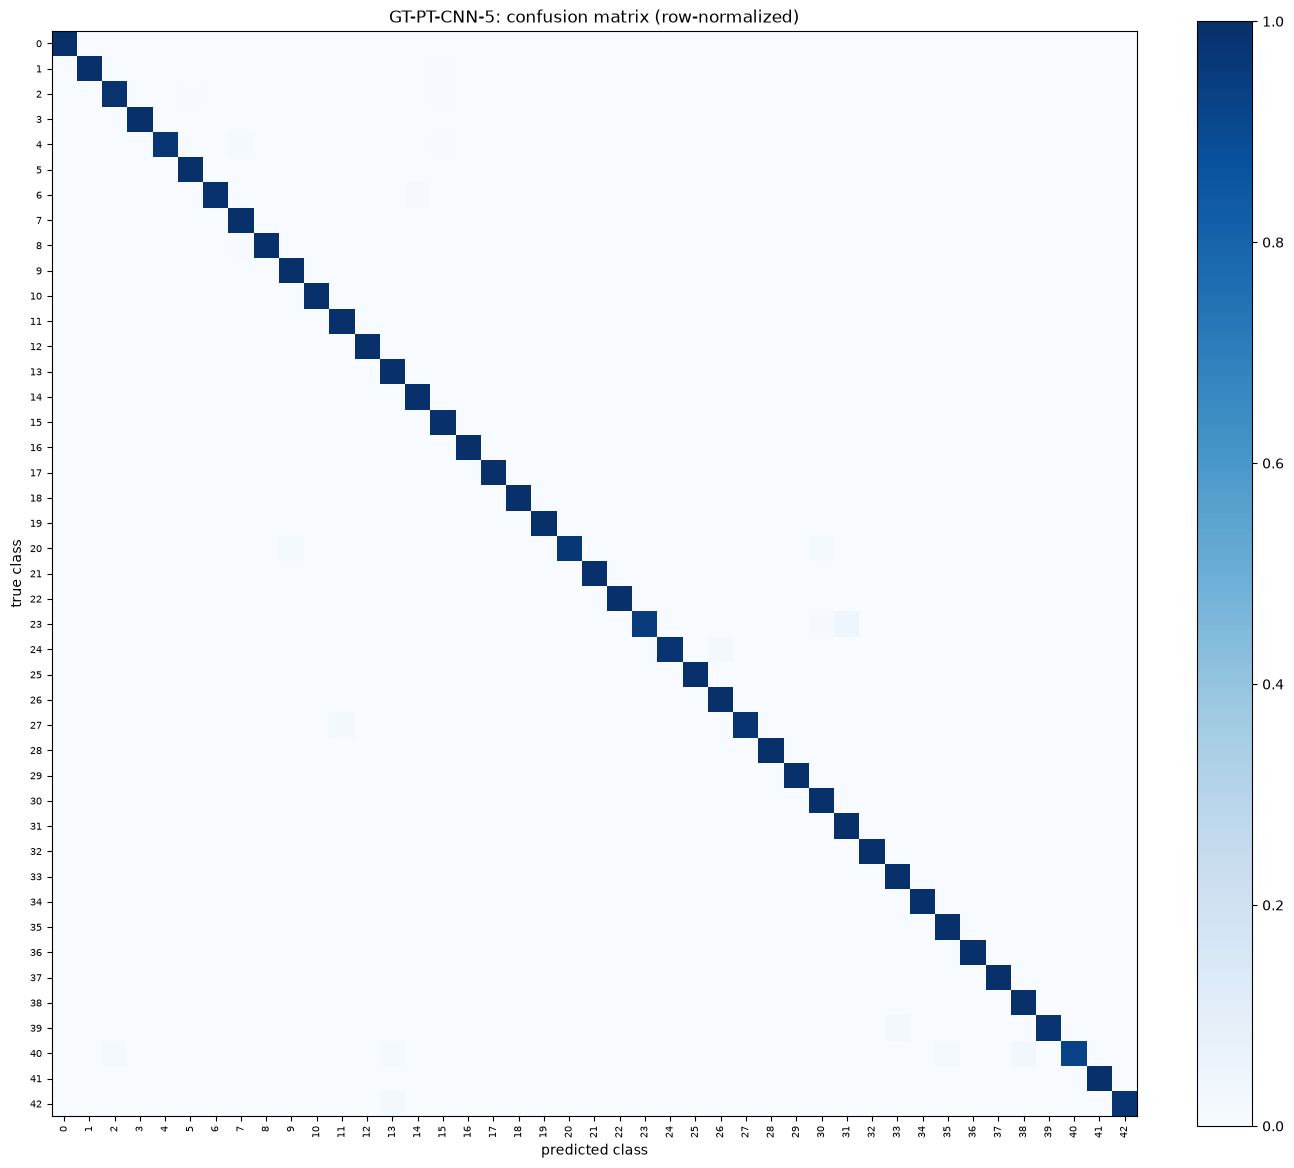

In [26]:
pt_models["CNN-5"], pt_preds["CNN-5"], _ = run_pt("CNN-5")

### 5.6 What the first layer learned
Filters come from `features[0].weight` `(32, 3, 3, 3)`; feature maps are saved by a **forward hook** on the first ReLU.

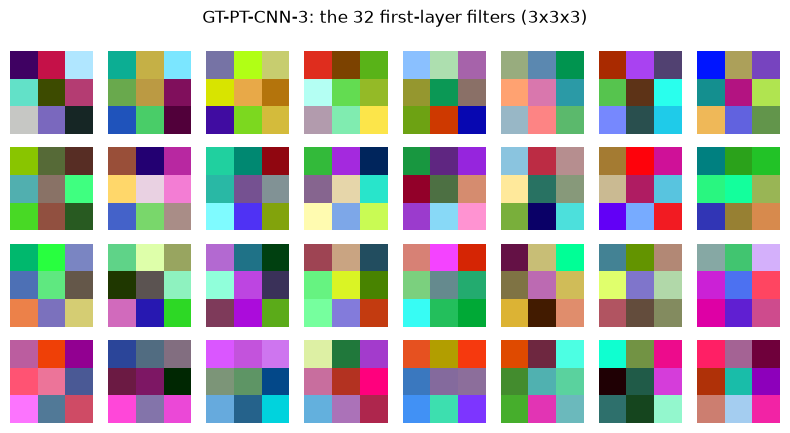

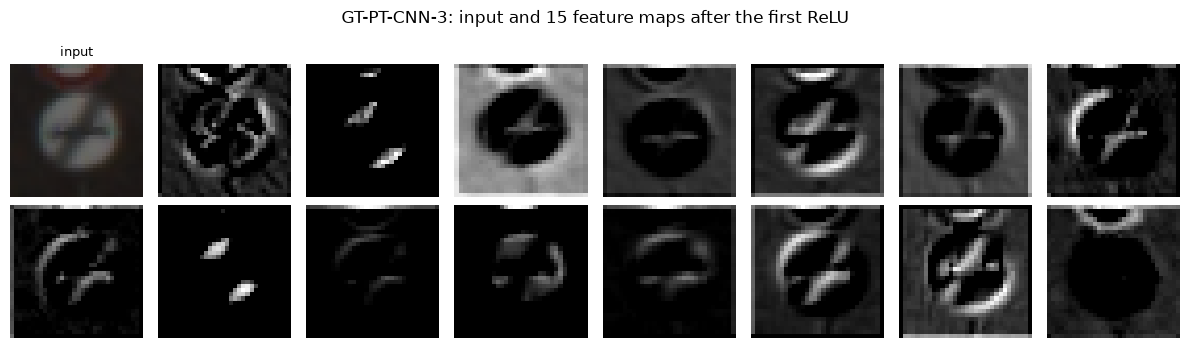

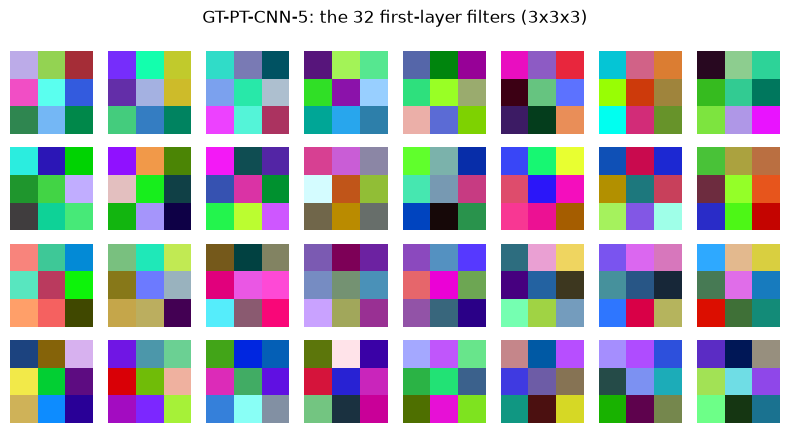

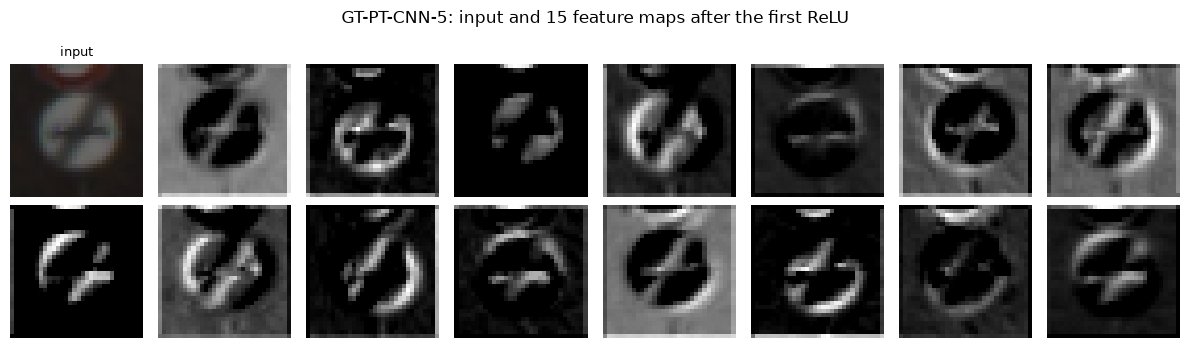

In [27]:
def pt_filters(m):
    return pt_models[m].features[0].weight.detach().cpu().numpy().transpose(0, 2, 3, 1)   # (F, K, K, C_in)


def pt_maps(m):
    model, captured = pt_models[m].eval(), {}
    relu = next(l for l in model.features if isinstance(l, nn.ReLU))
    handle = relu.register_forward_hook(lambda mod, inp, out: captured.update(out=out))
    with torch.no_grad():
        model(torch.from_numpy(np.transpose(sample, (0, 3, 1, 2))).to(DEVICE))
    handle.remove()
    return captured["out"][0].cpu().numpy()                                               # (F, H, W)


for m in MODELS:
    show_filters(pt_filters(m), f"{DATASET}-PT-{m}")
    show_feature_maps(pt_maps(m), f"{DATASET}-PT-{m}")

### 5.7 Errors

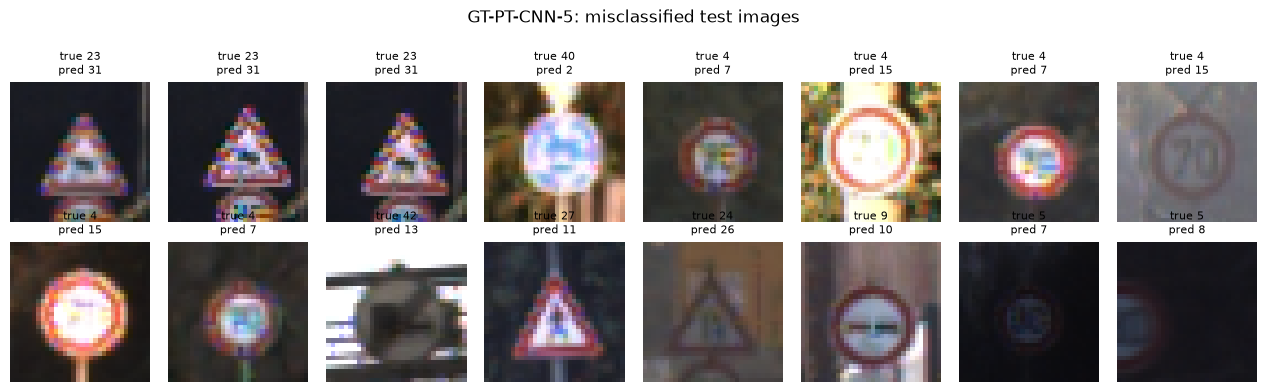

In [28]:
show_misclassified(pt_preds["CNN-5"], f"{DATASET}-PT-CNN-5")

## 6. Comparison

Read from the four `results/<run_id>.json` files. Macro F1 is the key column here because of the class imbalance.

In [29]:
records = load_results(RUN_IDS)
comparison = results_table(records)
comparison.to_csv(RESULTS_DIR / f"{DATASET}_comparison.csv")
comparison.round(4)

,framework,model,params,epochs,time_per_epoch_s,train_time_s,inference_ms_per_1k,accuracy,precision_macro,recall_macro,f1_macro
run_id,,,,,,,,,,,
GT-TF-CNN-3,TF,CNN-3,137771,20,23.3291,470.4519,0.1194,0.9781,0.9779,0.9740,0.9751
GT-TF-CNN-5,TF,CNN-5,184139,11,45.5476,507.0879,0.2196,0.9911,0.9921,0.9895,0.9907
GT-PT-CNN-3,PT,CNN-3,137771,20,25.8777,518.2704,0.2780,0.9848,0.9842,0.9849,0.9843
GT-PT-CNN-5,PT,CNN-5,184139,16,52.8365,846.0174,0.5006,0.9943,0.9948,0.9927,0.9937


Charts (two per figure) and the differences **CNN-5 − CNN-3** and **PT − TF**.

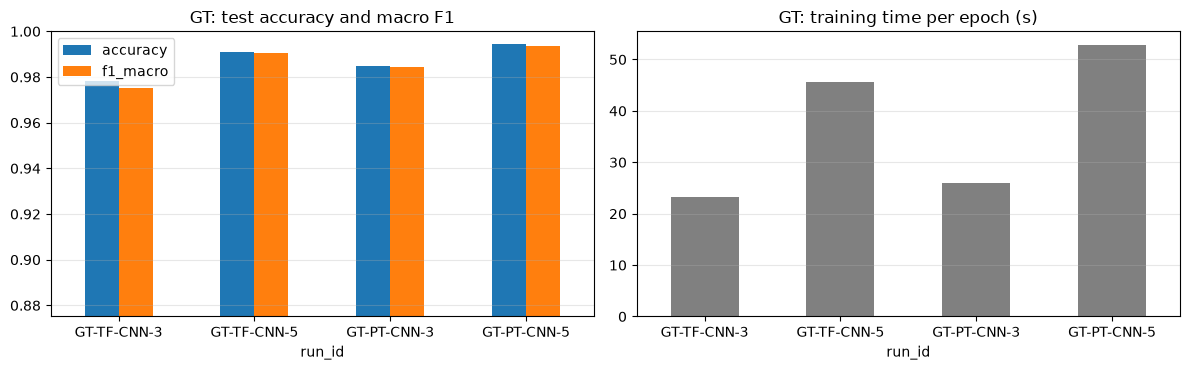

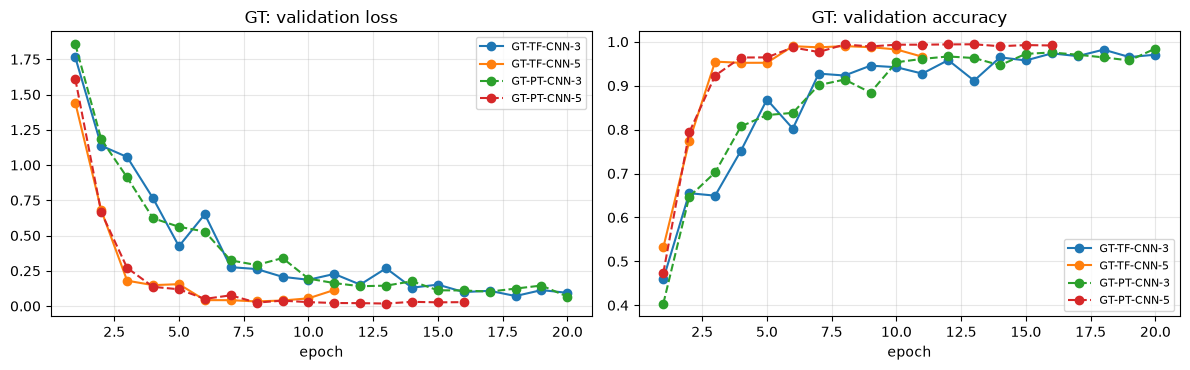

CNN-5 minus CNN-3 (per framework):


,accuracy,f1_macro,params,time_per_epoch_s,epochs
TF,0.0130,0.0156,46368.0,22.2185,-9.0
PT,0.0095,0.0094,46368.0,26.9588,-4.0


PT minus TF (per model):


,accuracy,f1_macro,params,time_per_epoch_s,epochs
CNN-3,0.0067,0.0092,0.0,2.5486,0.0
CNN-5,0.0032,0.0029,0.0,7.2889,5.0


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
comparison[["accuracy", "f1_macro"]].plot.bar(ax=axes[0], rot=0)
axes[0].set_ylim(max(0, comparison[["accuracy", "f1_macro"]].min().min() - 0.1), 1)
axes[0].set_title(f"{DATASET}: test accuracy and macro F1"); axes[0].grid(axis="y", alpha=0.3)
comparison["time_per_epoch_s"].plot.bar(ax=axes[1], rot=0, color="gray")
axes[1].set_title(f"{DATASET}: training time per epoch (s)"); axes[1].grid(axis="y", alpha=0.3)
fig.tight_layout(); savefig(fig, f"{DATASET}_comparison_bars"); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for r in records:
    style = "-" if r["framework"] == "TF" else "--"
    ep = np.arange(1, len(r["history"]["val_loss"]) + 1)
    axes[0].plot(ep, r["history"]["val_loss"], style, marker="o", label=r["run_id"])
    axes[1].plot(ep, r["history"]["val_accuracy"], style, marker="o", label=r["run_id"])
axes[0].set_title(f"{DATASET}: validation loss"); axes[1].set_title(f"{DATASET}: validation accuracy")
for ax in axes:
    ax.set_xlabel("epoch"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.tight_layout(); savefig(fig, f"{DATASET}_comparison_curves"); plt.show()

cols = ["accuracy", "f1_macro", "params", "time_per_epoch_s", "epochs"]
by = comparison.set_index(["framework", "model"])[cols]
print("CNN-5 minus CNN-3 (per framework):")
display(pd.DataFrame({fw: by.loc[(fw, "CNN-5")] - by.loc[(fw, "CNN-3")] for fw in FRAMEWORKS}).T.round(4))
print("PT minus TF (per model):")
display(pd.DataFrame({m: by.loc[("PT", m)] - by.loc[("TF", m)] for m in MODELS}).T.round(4))

**Discussion**

| | CNN-3 | CNN-5 | CNN-5 − CNN-3 |
|---|---|---|---|
| TF macro F1 | 0.9751 | 0.9907 | +0.0156 |
| PT macro F1 | 0.9843 | 0.9937 | +0.0094 |
| TF s/epoch | 23.3 | 45.5 | ×1.95 |
| PT s/epoch | 25.9 | 52.8 | ×2.04 |

- **Depth helps, including rare signs.** Macro F1 weights all 43 classes equally, so its gain (+0.009 to +0.016) shows CNN-5 also improves the small classes (some have only ~190 images), not just the frequent speed limits.
- **CNN-3 had not finished.** Both CNN-3 runs used all 20 epochs (the TF best epoch was the last one). With more epochs CNN-3 would likely close part of the gap; CNN-5 stopped early (11 and 16 epochs).
- **Frameworks.** PT is 0.003–0.007 higher in accuracy here; the gap is small and within single-seed noise. Keras was 11–16% faster per epoch on this CPU run.
- **Errors.** The confusion matrix is almost purely diagonal; the lightest diagonal cell is class 40 (Roundabout mandatory). The misclassified grid shows mostly very dark or blurred signs.

## 7. Conclusion

1. GTSRB is learned almost perfectly: best model `GT-PT-CNN-5`, accuracy 0.9943, macro F1 0.9937.
2. CNN-5 beats CNN-3 in both frameworks, and the gain holds under macro F1, so rare signs benefit too.
3. BatchNorm lets both depths train well despite the very uneven lighting of the photos.
4. Keras and PyTorch reach the same level (≤ 0.009 macro F1 apart); the 20-epoch limit, not the framework, limits CNN-3.